# **Customer Churn Exploratory Data Analysis**

# 1. INTRODUCTION

Customer churn significantly impacts subscription-based businesses.  
Understanding the behavioral patterns of customers who leave can help companies design better retention strategies.

This analysis aims to identify key factors associated with churn and generate insights that can support customer retention efforts.

My aim is to answer key questions relevant to the data analysis of our data set:
- Which customers churn the most?
- Which subscription type is most profitable?
- What behavioral patterns lead to churn?

# **Outline**
- Import libraries
- Explore Dataset
- Clean dataset
- Visualize data
- Business insights
  

# 2. Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print('Complete')

Complete


# 3. Load and inspect the dataset

The head function returns the first 5 rows of the dataset.

Each entry of the dataset represent an individual client and their attributes(age,gender,Subscription type,Total spend,churn etc.).
Based of these attributes,I will investigate the likelyhood of a client churning and what might have led to that

In [12]:
churn_dataset=(r"C:\Users\Admin\Desktop\Data Science projects\customer_churn_dataset-training-master.csv")
churn_data= pd.read_csv(churn_dataset)
churn_data.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


# 4. Data Exploration

In [8]:
churn_data.shape

(440833, 12)

The dataset is comprised of 12 attrubutes and 440833 rows(entries)

In [8]:
churn_data.duplicated().sum()

np.int64(0)

There are no duplicated values in our dataset

In [9]:
churn_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


The info() function gives an overview of our data; The dataset contains 440,833 observations and 12 variables.

All variables have complete records, indicating no missing values.

There are 9 float and 3 string  data types

However, the churn column has a wrong datatype( float instead of boolean)

I will proceed to change this data type with th astype function

In [9]:
churn_data['Churn']=churn_data['Churn'].astype(bool)
churn_data.dtypes

CustomerID           float64
Age                  float64
Gender                   str
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type        str
Contract Length          str
Total Spend          float64
Last Interaction     float64
Churn                   bool
Spend Category           str
dtype: object

In [36]:
churn_data.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='str')

*The dataset has the following attributes*:
- Age- client's age(numeric)
- Gender- Client's Gender(Categorical; Male or Female)
- Tenure- How long they are subscribed for(Numeric)
- Usage Frequency- How often they use the service(Numeric)
- Support calls- How many calls they make asking for assistance( Numeric)
- Payment delay- How long they Take to renew their subscription(Numeric)
- Subscription type- The type of package they are subscribed to(Categorical;Premium,Standard,Basic)
- Contract Length; For how long does their subscription run(Categorical;Annual,Quarterly,Monthly)
- Total sepnd- How much has the client already spent(Numeric)
- Churn- Whether the client ancelled their subscription( boolean; 1 or 0)

In [69]:
churn_data.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000


The describe function gives us summary statistics from all numeric columns

The average client is 39 years old, made 3 support calls and spent around 631 dollars on the service

In [156]:
churn_data.describe(include='object')

C:\Users\Admin\AppData\Local\Temp\ipykernel_18464\1680030407.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  churn_data.describe(include='object')


,Gender,Subscription Type,Contract Length
count,440832,440832,440832
unique,2,3,3
top,Male,Standard,Annual
freq,250252,149128,177198


Adding the include gives the summary statistics for the categorical attributes

The average client is male ,has subscribed to the standard package and renews their contract annualy

In [46]:
churn_data['Gender'].value_counts()

Gender
Male      250252
Female    190580
Name: count, dtype: int64

In [52]:
churn_data['Subscription Type'].value_counts()

Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

In [53]:
churn_data['Contract Length'].value_counts()

Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64

I have used the value counts function to get the count for each distinct category entry from our cattegorical attributes

There are more males than females subscribed. most clients are subscribed to the standard package and they renew their contracts annualy

# Univariate Analysis

The goal of this section is to investigate how individual factors are distributed and how they affect the churn rate 

# Churn Distributions

In [74]:
churn_data.groupby('Churn').size()

Churn
False    190833
True     250000
dtype: int64

Text(0.5, 1.0, 'Customer Churn Distribution')

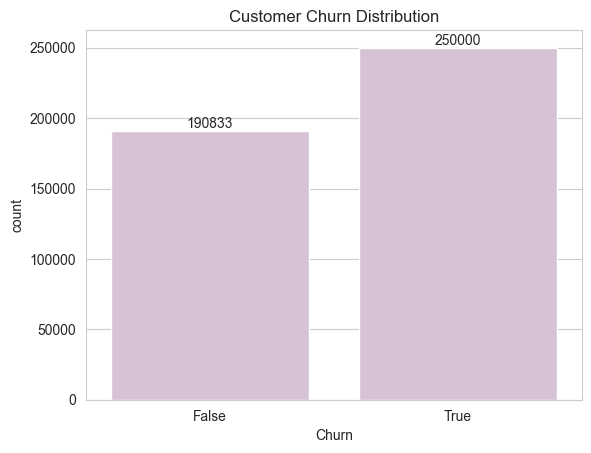

In [132]:
ax=sns.countplot(x='Churn', data=churn_data,color=('thistle'))
sns.set_style('darkgrid')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Customer Churn Distribution")

- This bar chart shows the counts for those who churned versus those whon were retained
- The churned customers represent approximately 57% of the total and retained customers making up the remaining 43%.
-  This means the business is currently losing more customers than it is keeping 

# Churn by Subscription type

In [137]:
churn_data.groupby('Subscription Type').size()

Subscription Type
Basic       143026
Premium     148678
Standard    149128
dtype: int64

Text(0.5, 1.0, 'Subscription Type Distribution')

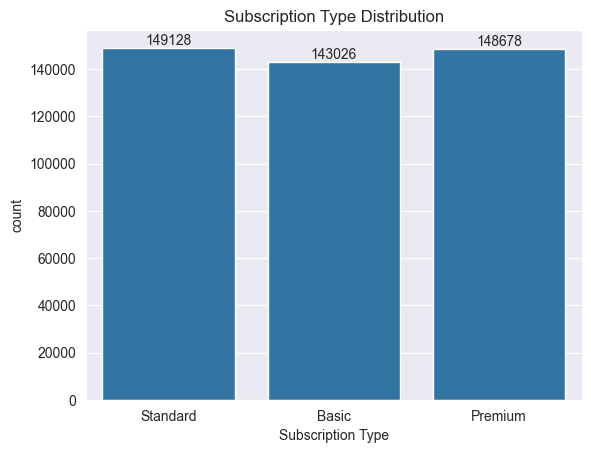

In [143]:
ax=sns.countplot(x='Subscription Type',data=churn_data)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Subscription Type Distribution')


- The plot shows how many customers are subscribed to each package
- The most popular package is the standard and the least popular being basic

In [82]:
churn_data.groupby(['Subscription Type','Churn'])['Churn'].value_counts()

Subscription Type  Churn
Basic              False    59816
                   True     83210
Premium            False    65505
                   True     83173
Standard           False    65512
                   True     83616
Name: count, dtype: int64

Text(0.5, 1.0, 'Churn by Subscription Type')

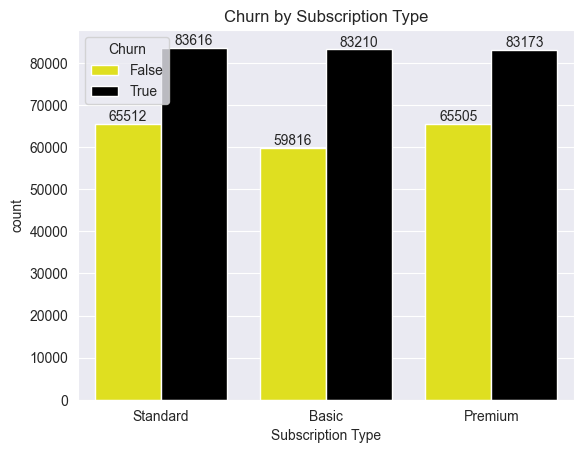

In [157]:
ax=sns.countplot(x='Subscription Type',hue='Churn',data=churn_data,palette=['yellow','black'])
for container in ax.containers:
    ax.bar_label(container)
plt.title('Churn by Subscription Type')

Observation:
- The grouped bar chart compares churned and non-churned  customer counts across three subscription types. In all three categories, churned customers outnumber non-churned ones.

Explanation:
- The near- churn counts across all three subscription types suggest that subscription package has very little influence on whether a customer churns. Churn appears to be driven by other factors.
- Basic subscribers have the lowest retention count.

Business Insight:
- The company may benefit from investigating factors beyond subscription type that are driving the uniformly high churn across all tiers

# Churn distribtuion by Gender

In [202]:
churn_data.groupby('Gender')['Total Spend'].sum()/ churn_data['Total Spend'].sum() * 100

Gender
Female    41.982745
Male      58.017255
Name: Total Spend, dtype: float64

The male population makes about 58% of the total spend while wommen make up about 42%

In [203]:
churn_data.groupby('Gender')['Churn'].mean()*100

Gender
Female    66.669115
Male      49.126880
Name: Churn, dtype: float64

About 67% of the female population churned and only about 49% for males churned

Text(0.5, 1.0, 'Churn by Gender')

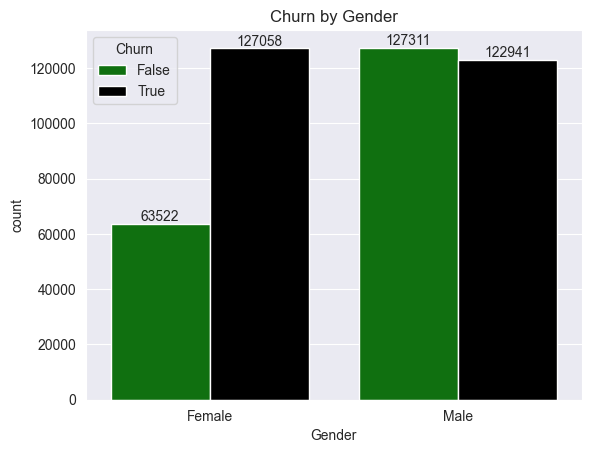

In [165]:
ax=sns.countplot(x='Gender',hue='Churn',data=churn_data,palette=['Green','Black'])
for container in ax.containers:
    ax.bar_label(container)
plt.title('Churn by Gender')

Observation:
- The grouped bar chart shows churn rate split by gender
- Female customers have a significantly lower non-churn count compared to their churn count, reflecting a roughly 2:1 churn-to-retention ratio.
- However, Male customers show a more balanced pattern nearly equal counts between those who churned and those that did not

Explanation:
- Female customers churn at roughly twice the rate they are retained, while male customers churn and stay at almost the same rate.
-  This suggests that the service may be less aligned with the needs of female customers.

Business insight:
- The company should look into identifying needs relevant to the female population
- Structure campgains around retention of the female customer base


# Churn distribution by Age

Text(0.5, 1.0, 'Age distributions')

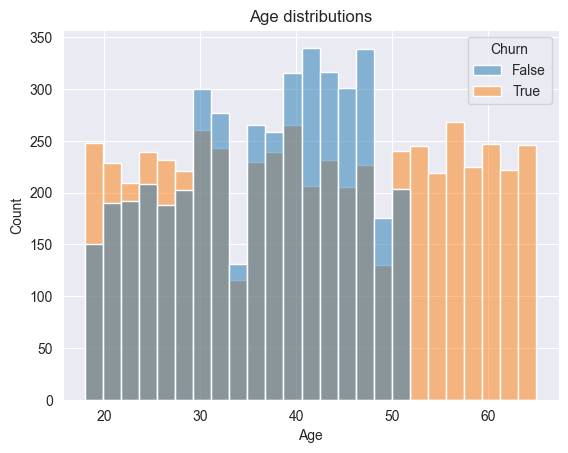

In [168]:
sns.histplot(data=sample_data,x='Age',bins=25,hue='Churn')
plt.title('Age distributions')

Observation:
- The histogram shows the distribution of customer ages segmented by churn status. Customers who churn appear to be more concentrated in the older age ranges (around 50–65), while non-churning customers are more  in the 30–50 age range.

Explanation:
- This suggests that older customers may be more likely to cancel their subscriptions, while middle-aged customers appear to maintain longer subscriptions to the service.

Business Insight:

The company may benefit from:
- Identifying customer needs specific to older age groups
- Improving product support for older users
- Creating targeted retention campaigns for higher-risk age segments

Text(0.5, 1.0, 'Age distributions')

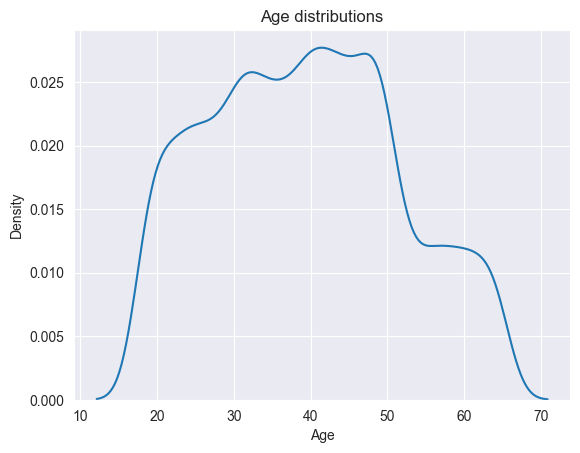

In [171]:
sns.kdeplot(data=sample_data,x='Age')
plt.title('Age distributions')

# Spending Distributions

In [127]:
churn_data.groupby(['Subscription Type','Contract Length'])['Total Spend'].sum().round()

Subscription Type  Contract Length
Basic              Annual             37293392.0
                   Monthly            15986965.0
                   Quarterly          36636299.0
Premium            Annual             39045478.0
                   Monthly            15957431.0
                   Quarterly          39099332.0
Standard           Annual             39140415.0
                   Monthly            16016639.0
                   Quarterly          39260693.0
Name: Total Spend, dtype: float64

Text(0.5, 1.0, 'Spending Distributions')

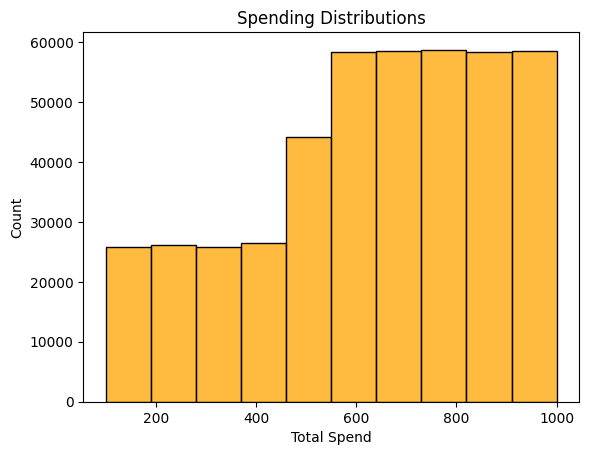

In [119]:
sns.histplot(churn_data['Total Spend'],bins=10,color=('orange'))
plt.title('Spending Distributions')

Observation:
- The histogram shows the distribution of total customer spend. The distribution is right-skewed; it's relatively flat and low (around 26,000) for spending between 100–400, then rise sharply and plateau at approximately 58,000 for spending between 600-1,000.

Explanation:
- The sharp jump around the 500 mark suggests there may be two distinct customer spending segments; a lower-spend and a higher-spend group. The plateau at the higher end indicates a large concentration of customers who consistently spend $600+ possibly reflecting subscription packages or pricing plans

Business Insight:

The company may benefit from:

- Investigating what drives the spending jump around $500
- Analysing whether the two spending clusters correspond to different customer profiles or demographics


Text(0.5, 1.0, 'Density plot for the spending distribution')

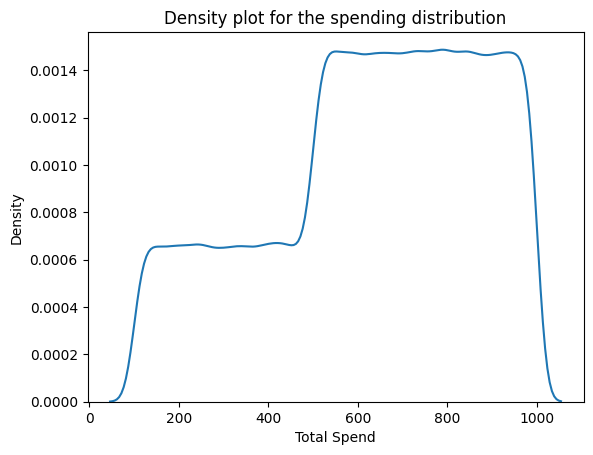

In [122]:
sns.kdeplot(churn_data['Total Spend'])
plt.title('Density plot for the spending distribution')

# Bivariate Analysis

The goal of this section is to investigate the correlation between factors and how they affect the churn rate

**Boxplots**

Text(0.5, 1.0, 'Payment Delays vs Churn')

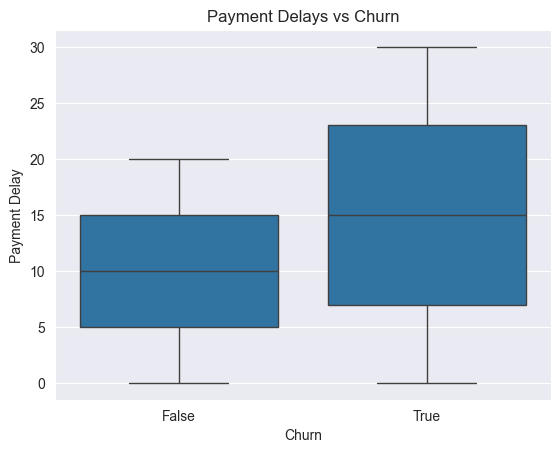

In [195]:
sns.boxplot(x='Churn', y='Payment Delay', data=churn_data)
plt.title('Payment Delays vs Churn')

Observation:

- The box plot compares payment delay distributions between churned  and non-churned  customers. Non-churning customers have a median payment delay of around 10 days with a narrow interquartile range (roughly 7–15), while churned customers show a higher median of around 15 days and a much wider spread (roughly 8–23) with a maximum reaching 30 days.

Explanation:
- Churned customers  exhibit longer and more variable payment delays compared to those who stayed. This suggests that payment delay behaviour is a meaningful signal of customer dissatisfaction or financial constraints, both of which may lead to cancellation.

Business Insight:

The company may benefit from:

- Setting up early-warning alerts when a customer's payment delay exceeds a threshold (15+ days)
- Proactively reaching out to customers with deteriorating payment behaviour before they churn
- Offering flexible payment options to retain high churn risk customers

In [160]:
sample_data = churn_data.sample(10000)

**Scatterplot**

Text(0.5, 1.0, 'Customer Tenure vs Total Spend')

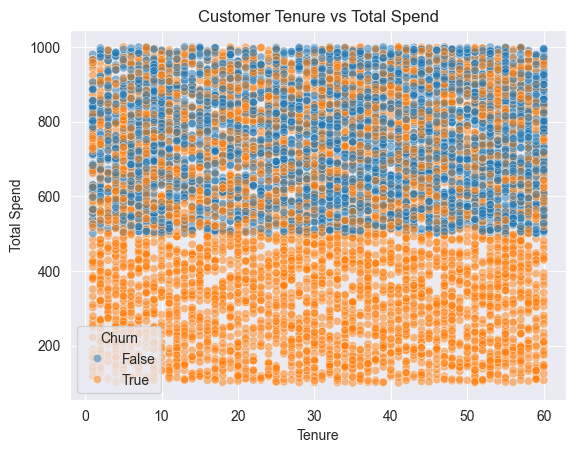

In [194]:
sns.scatterplot(x='Tenure', y='Total Spend', hue='Churn', data=sample_data,alpha=0.5)
plt.title("Customer Tenure vs Total Spend")

Observation:

- The scatter plot maps customer tenure  against total spend, coloured by churn status. Churned customers (orange) are heavily concentrated in the lower spend range (below 500) across all tenure lengths, while non-churned customers (blue) are  found in the higher spend range (above 500), also across all tenure lengths.

Explanation:
- There's a horizontal spending threshold around $500 that separates the two churn groups.
- Tenure does not appear to strongly differentiate churned from non-churned customers suggesting that how much a customer spends matters more than how long they've been with the subscribed for.

Business Insight:

The company may benefit from:

- Prioritising total spend as a key churn predictor over tenure in retention models
- Investigating why low-spend customers churn regardless of how long they've been subscribed

In [6]:
churn_data['Spend Category'] = churn_data['Total Spend'].apply(
    lambda x: 'Low Spend (<500)' if x < 500 else 'High Spend (>=500)')
churn_data.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Spend Category
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,High Spend (>=500)
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,High Spend (>=500)
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,Low Spend (<500)
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,Low Spend (<500)
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,High Spend (>=500)


In [180]:
churn_data['Spend Category'].value_counts()

Spend Category
High Spend (>=500)    325037
Low Spend (<500)      115796
Name: count, dtype: int64

In [186]:
churn_data.groupby('Spend Category')['Churn'].mean()*100

Spend Category
High Spend (>=500)     41.288838
Low Spend (<500)      100.000000
Name: Churn, dtype: float64

Around 41% of the higher spenders churned while 100 %of the lower spenders churned

Text(0.5, 1.0, 'Churn rate by spending category')

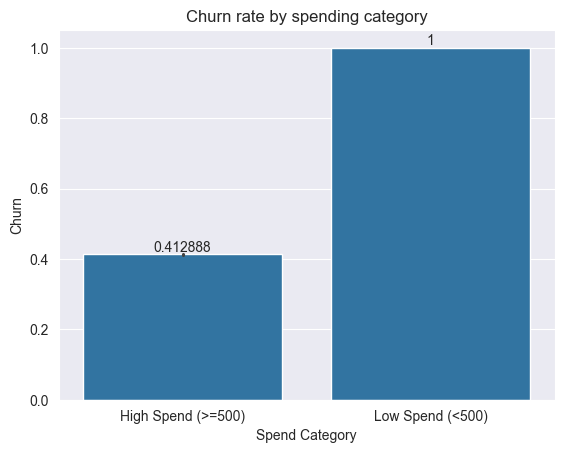

In [191]:
ax=sns.barplot(data=churn_data,x='Spend Category',y='Churn')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Churn rate by spending category')

Observation:
- The bar chart shows churn rates split by spending category. Low-spend customers  have a churn rate of exactly  100%, while high-spend customers  have a churn rate of approximately  41%.

Explanation:
- Every single low-spend customer in the dataset has churned, making spending level an extremely powerful churn indicator for that segment. High-spend customers are significantly more likely to stay, suggesting that spending level correlates with customer engagement.

Business Insight:

The company may benefit from:

- Treating all low-spend customers as high-risk and intervening early with targeted retention efforts
- Setting a spend threshold below which proactive outreach is automatically triggered

# Key business Insights

**1. The company is losing more customers than it retains**
- Approximately 57% of customers churn while only 43% remain, indicating a serious retention problem. This suggests the company should prioritize customer retention strategies rather than focusing only on new customer acquisition.

**2. Female customers churn at significantly higher rates**
- Female customers exhibit a much higher churn rate (67%) compared to male customers (49%).

**3. Older customers appear more likely to churn**
- Customers who churn are more concentrated in the 50–65 age range, while retained customers are more common in the 30–50 range.

**4. Customer spending forms two distinct segments**
- Customer spending shows a clear split between lower spenders and higher spenders, with a noticeable threshold around $500.

**5. Payment delays are a strong signal of churn risk**
- Customers who churn tend to have longer and more inconsistent payment delays than those who remain subscribed.

**6. Low-spend customers represent an extremely high churn-risk group**
- The analysis shows all low-spend customers eventually churn, while high-spend customers churn at a much lower rate (~41%).
- This suggests that low spending is strongly associated with low engagement and high churn risk.